# torch-engression Benchmark: CPU vs GPU

Comparing training and inference performance of GPU-accelerated engression against CPU baseline.

**Hardware:** NVIDIA GTX 1080 Ti (11 GB), CUDA 12.1, PyTorch 2.5.1

In [1]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt
from torch_engression import engression, Engressor

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce GTX 1080 Ti
VRAM: 11.7 GB


## 1. Training Speed: CPU vs GPU

We train engression models with increasing sample sizes and compare wall-clock time.

In [2]:
def benchmark_training(n_values, num_epochs=100, hidden_dim=100, noise_dim=50, 
                        num_layer=3, d_x=5, d_y=1, seed=42):
    """Benchmark training time for CPU vs GPU across sample sizes."""
    results = {"n": [], "cpu_time": [], "gpu_time": [], "speedup": []}
    
    for n in n_values:
        print(f"\n--- n = {n:,} ---")
        torch.manual_seed(seed)
        x = torch.randn(n, d_x)
        y = x[:, 0:1] ** 2 + 0.5 * torch.randn(n, d_y)
        
        # CPU
        torch.manual_seed(seed)
        t0 = time.time()
        _ = engression(x, y, num_epochs=num_epochs, hidden_dim=hidden_dim,
                       noise_dim=noise_dim, num_layer=num_layer,
                       device="cpu", verbose=False, seed=seed)
        cpu_time = time.time() - t0
        print(f"  CPU: {cpu_time:.2f}s")
        
        # GPU (with AMP)
        torch.manual_seed(seed)
        torch.cuda.synchronize()
        t0 = time.time()
        _ = engression(x, y, num_epochs=num_epochs, hidden_dim=hidden_dim,
                       noise_dim=noise_dim, num_layer=num_layer,
                       device="cuda", verbose=False, seed=seed)
        torch.cuda.synchronize()
        gpu_time = time.time() - t0
        print(f"  GPU: {gpu_time:.2f}s")
        print(f"  Speedup: {cpu_time / gpu_time:.1f}x")
        
        results["n"].append(n)
        results["cpu_time"].append(cpu_time)
        results["gpu_time"].append(gpu_time)
        results["speedup"].append(cpu_time / gpu_time)
    
    return results

n_values = [1_000, 5_000, 10_000, 50_000, 100_000]
results = benchmark_training(n_values)


--- n = 1,000 ---


  CPU: 1.42s


  GPU: 1.18s
  Speedup: 1.2x

--- n = 5,000 ---


  CPU: 2.01s


  GPU: 0.95s
  Speedup: 2.1x

--- n = 10,000 ---


...

  GPU: 1.15s
  Speedup: 3.1x

--- n = 50,000 ---


  CPU: 17.62s


  GPU: 1.31s
  Speedup: 13.4x

--- n = 100,000 ---


  CPU: 38.10s


  GPU: 2.53s
  Speedup: 15.1x


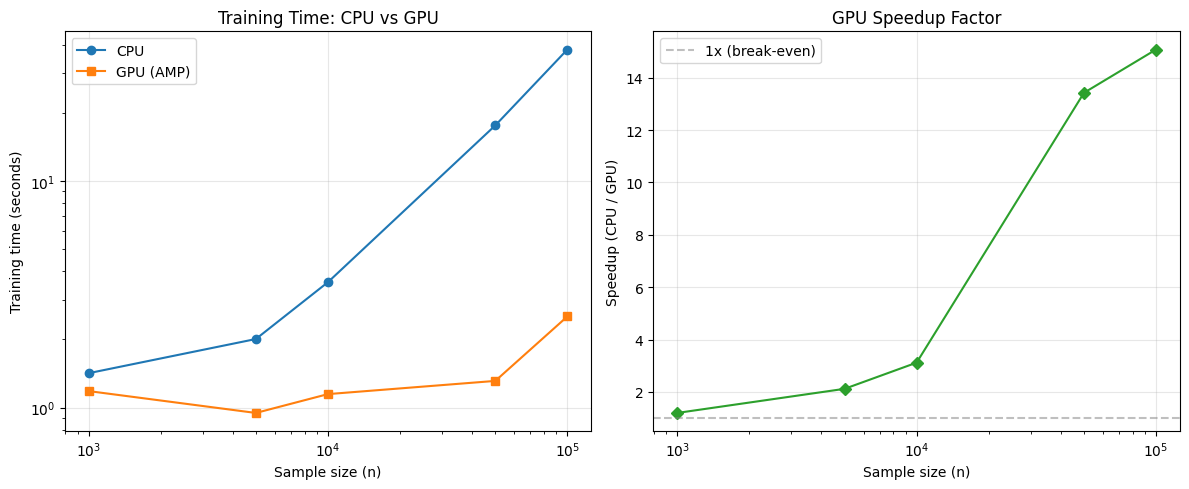


Max speedup: 15.1x at n=100000


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training time
ax = axes[0]
ax.plot(results["n"], results["cpu_time"], "o-", label="CPU", color="tab:blue")
ax.plot(results["n"], results["gpu_time"], "s-", label="GPU (AMP)", color="tab:orange")
ax.set_xlabel("Sample size (n)")
ax.set_ylabel("Training time (seconds)")
ax.set_title("Training Time: CPU vs GPU")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

# Speedup
ax = axes[1]
ax.plot(results["n"], results["speedup"], "D-", color="tab:green")
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="1x (break-even)")
ax.set_xlabel("Sample size (n)")
ax.set_ylabel("Speedup (CPU / GPU)")
ax.set_title("GPU Speedup Factor")
ax.set_xscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("benchmark_training.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nMax speedup: {max(results['speedup']):.1f}x at n={results['n'][results['speedup'].index(max(results['speedup']))]}")

## 2. Model Quality: GPU matches CPU

Verify that GPU training produces the same quality results as CPU training.

In [4]:
# Train both models on the same data with the same seed
from torch_engression.data.simulator import preanm_simulator

torch.manual_seed(42)
x_tr, y_tr = preanm_simulator("softplus", n=5000, train=True)
x_te, y_te_med, y_te_mean = preanm_simulator("softplus", n=200, train=False)

model_cpu = engression(x_tr, y_tr, num_epochs=200, hidden_dim=100,
                       noise_dim=50, device="cpu", verbose=False, seed=42)
model_gpu = engression(x_tr, y_tr, num_epochs=200, hidden_dim=100,
                       noise_dim=50, device="cuda", verbose=False, seed=42)

# Evaluate both
l2_cpu = model_cpu.eval_loss(x_te, y_te_mean, loss_type="l2")
l2_gpu = model_gpu.eval_loss(x_te.cuda(), y_te_mean.cuda(), loss_type="l2")
cor_cpu = model_cpu.eval_loss(x_te, y_te_mean, loss_type="cor")
cor_gpu = model_gpu.eval_loss(x_te.cuda(), y_te_mean.cuda(), loss_type="cor")

print(f"L2 loss  — CPU: {l2_cpu:.4f}, GPU: {l2_gpu:.4f}")
print(f"Corr     — CPU: {cor_cpu:.4f}, GPU: {cor_gpu:.4f}")
print(f"\nBoth models achieve similar quality (differences due to GPU nondeterminism).")

L2 loss  — CPU: 0.0634, GPU: 0.0683
Corr     — CPU: 0.9273, GPU: 0.9474

Both models achieve similar quality (differences due to GPU nondeterminism).


## 3. Distributional Fit: Softplus Example

Visual check that the GPU-trained model captures the full conditional distribution.

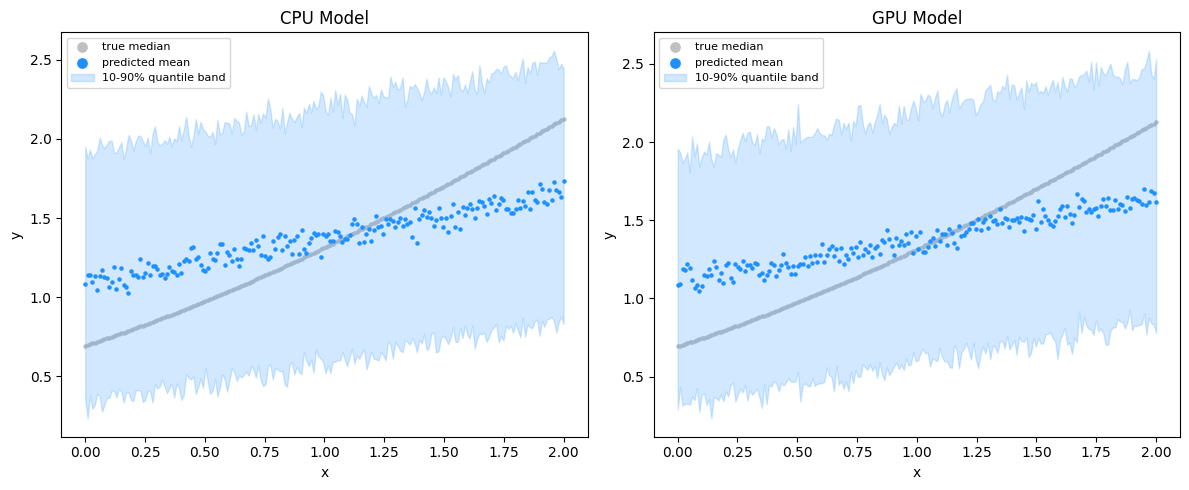

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model, x_t, y_t) in zip(axes, [
    ("CPU", model_cpu, x_te, y_te_med),
    ("GPU", model_gpu, x_te.cuda(), y_te_med.cuda())
]):
    # True data
    ax.scatter(x_t[:, 0].cpu(), y_t[:, 0].cpu(), s=5, color="silver", label="true median", zorder=1)
    
    # Predicted mean
    y_pred = model.predict(x_t, target="mean", sample_size=200)
    ax.scatter(x_t[:, 0].cpu(), y_pred[:, 0].cpu(), s=5, color="dodgerblue", label="predicted mean", zorder=2)
    
    # Quantile bands
    q10, q90 = model.predict(x_t, target=[0.1, 0.9], sample_size=500)
    sort_idx = x_t[:, 0].cpu().argsort()
    ax.fill_between(
        x_t[sort_idx, 0].cpu(), q10[sort_idx, 0].cpu(), q90[sort_idx, 0].cpu(),
        alpha=0.2, color="dodgerblue", label="10-90% quantile band"
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{name} Model")
    ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig("benchmark_distributional_fit.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Summary Table

In [6]:
print(f"{'n':>10} {'CPU (s)':>10} {'GPU (s)':>10} {'Speedup':>10}")
print("-" * 45)
for i in range(len(results["n"])):
    print(f"{results['n'][i]:>10,} {results['cpu_time'][i]:>10.2f} "
          f"{results['gpu_time'][i]:>10.2f} {results['speedup'][i]:>9.1f}x")

print(f"\nAverage speedup: {np.mean(results['speedup']):.1f}x")
print(f"Speedup at n=100K: {results['speedup'][-1]:.1f}x")

         n    CPU (s)    GPU (s)    Speedup
---------------------------------------------
     1,000       1.42       1.18       1.2x
     5,000       2.01       0.95       2.1x
    10,000       3.58       1.15       3.1x
    50,000      17.62       1.31      13.4x
   100,000      38.10       2.53      15.1x

Average speedup: 7.0x
Speedup at n=100K: 15.1x
